# Assignment 2: Linear Regression
Luiza Teodora Filip

s5183685

### Import the following libraries and required packages
- **pandas**: used for loading and working with the dataset
- **matplotlib**: used for creating plots and graphs
- **LinearRegression**: is the sklearn function that fits a simple linear regression model
- **r2_score**: measures how well the regression line fits the data
- **stats**: contains the Shapiro-Wilk normality test

In [147]:
# import all the libraries needed
import pandas as pd
from sklearn.feature_extraction import DictVectorizer
from collections import Counter
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from scipy import stats

### Loading the metadata file

In [148]:
# load the dataset
df = pd.read_csv("data_full_story.csv")
# Show the first 5 rows so we can check that the file loaded correctly
df.head()

,name,story_score,agency_score,event_score,world_score,suspense_score,surprise_score,curiosity_score
0,t1_c95k50u,0.000000,1.0,1.0,1.000000,2.75,2.25,1.75
1,t1_c95mz3n,0.857143,4.0,5.0,1.000000,2.75,2.75,3.25
2,t1_c95l4my,0.857143,4.0,4.0,1.000000,2.75,3.25,3.50
3,t1_c95mcms,0.857143,5.0,5.0,1.000000,3.25,4.00,2.50
4,t3_1aenyc,1.000000,5.0,5.0,3.666667,2.75,3.50,3.75


In [149]:
# Display all colunm names in the dataset
df.columns

Index(['name', 'story_score', 'agency_score', 'event_score', 'world_score',
       'suspense_score', 'surprise_score', 'curiosity_score'],
      dtype='str')

### Dependent and Independent variables
- **Dependent variable**: the variable you are trying to predict or explain
- **Independent variables**: they are the variables that might influence or explain the dependent variable

In [150]:
# Define the dependent variable
# In this assignment, that is the overall story strength score
y = df["story_score"]

In [151]:
# Define the independent variables (predictors)
# We will later test each one separately using simple linear regression
features = [
    "agency_score",
    "event_score",
    "world_score",
    "curiosity_score",
    "surprise_score",
    "suspense_score"
]

### Use matplotlib to plot scatterplots of the data
The scatterplots help us to visually see whether there is a linear relationship between each feature and 'story_score'

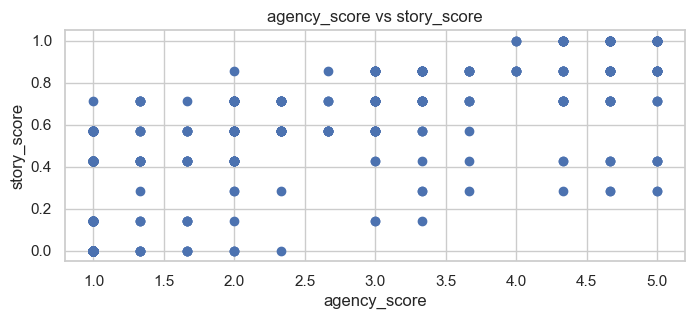

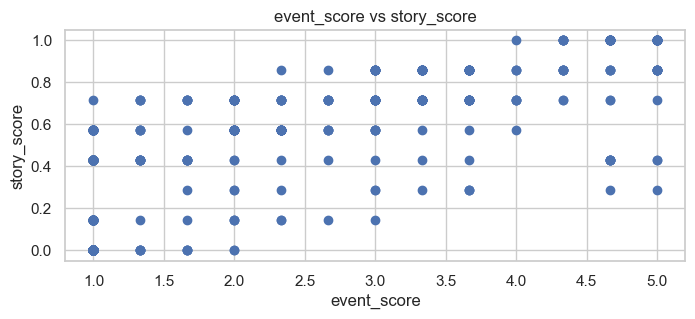

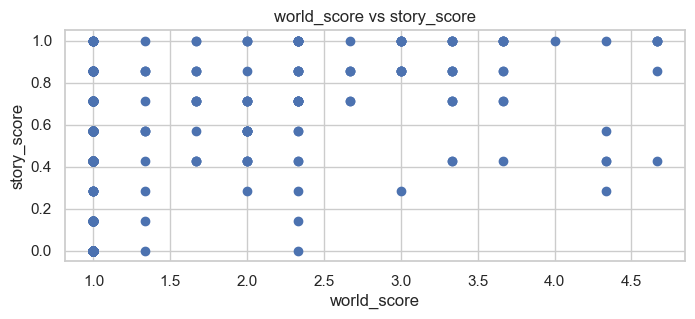

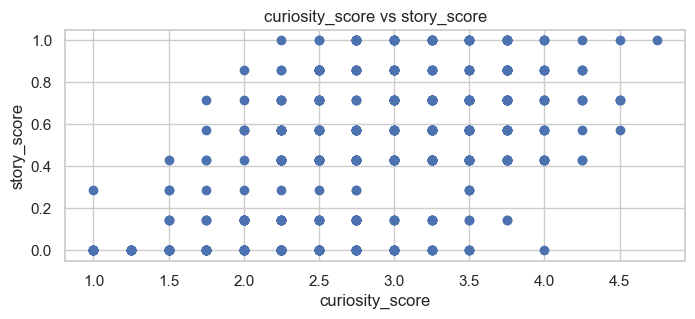

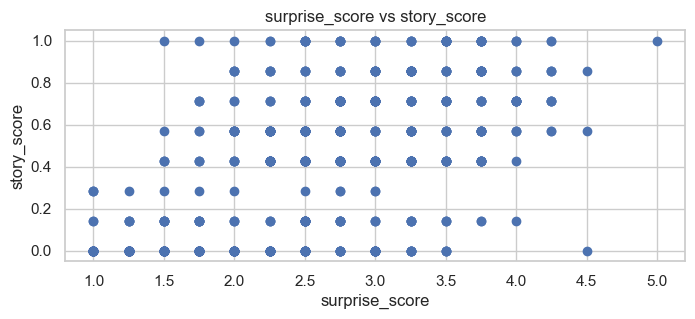

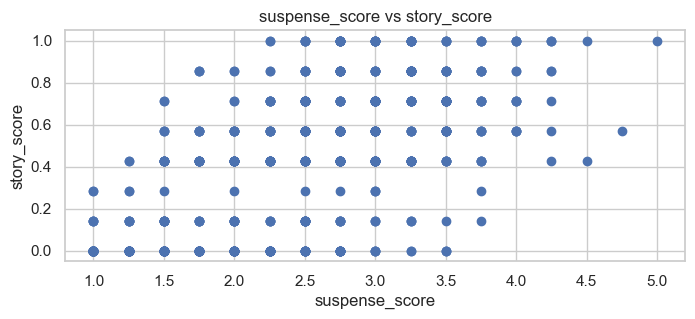

In [152]:
for feature in features:
    # create a new figure for each scatterplot
    plt.figure()
    # plot the independent variable on the x-axis
    # plot story_score on the y-axis
    plt.scatter(df[feature], y)
    # label the axes 
    plt.xlabel(feature)
    plt.ylabel("story_score")
    # adding a title to make the graph easy to understand 
    plt.title(f"{feature} vs story_score")
    
    plt.show()

### Perform Simple Linear Regression on the data in the columns
- **Intercept**: the predicted story_score when the feature equals 0
- **Slope**: how much story_score changes when the feature increases by 1
- **R²**: how much of the variation in story_score is explained by that predictor (independent variable)

In [153]:
# Create an empty list to store the regression results. This will later be displayed in a table
results = []

for feature in features:
    # X must be 2-dimensional for sklearn, so we use double brackets
    X = df[[feature]]
    # create the linear regression moddel
    model = LinearRegression()
    model.fit(X, y)
    
    predictions = model.predict(X)
    # extract the intercept and slope of the regression line
    intercept = model.intercept_
    slope = model.coef_[0]
    # calculate the R² value to measure goodness of fit using the predefined sklearn.metrics function
    r2 = r2_score(y, predictions)
    #print the results
    print(f"\nVariable: {feature}")
    print("Intercept:", intercept)
    print("Slope:", slope)
    print("R2 score:", r2)
    
    # Save results for later summary table
    results.append({
        "variable": feature,
        "intercept": intercept,
        "slope": slope,
        "r2_score": r2
    })


Variable: agency_score
Intercept: 0.024369675050673056
Slope: 0.18627994385726165
R2 score: 0.5808231102839131

Variable: event_score
Intercept: 0.020186836862851498
Slope: 0.19334793892265853
R2 score: 0.5971390119224571

Variable: world_score
Intercept: 0.14541022807542614
Slope: 0.20197244661380936
R2 score: 0.20441831933988508

Variable: curiosity_score
Intercept: -0.31947316124492475
Slope: 0.26549191225110275
R2 score: 0.36142282050508

Variable: surprise_score
Intercept: -0.2014076830342446
Slope: 0.23856645776524996
R2 score: 0.3427290841563503

Variable: suspense_score
Intercept: -0.21450119998638406
Slope: 0.2575710705260038
R2 score: 0.42143072641120327


### Plot regression lines
For each independent variable, plot a function based on the intercept and slope

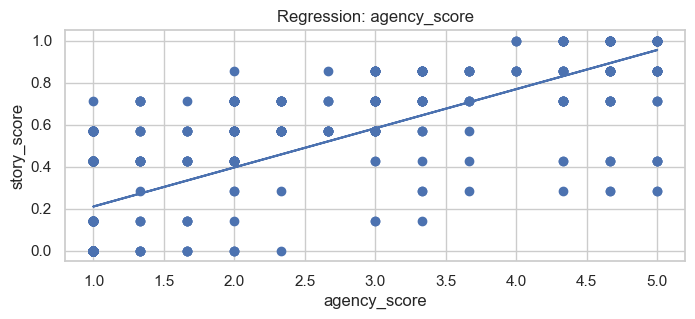

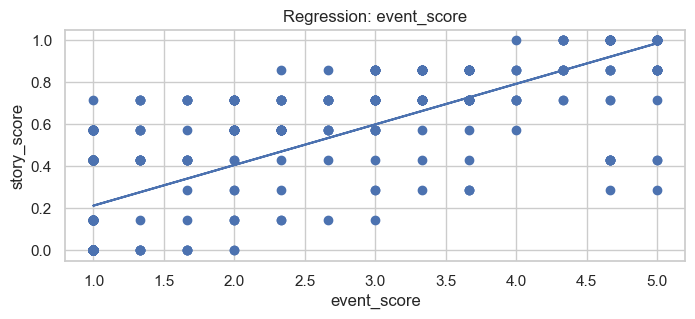

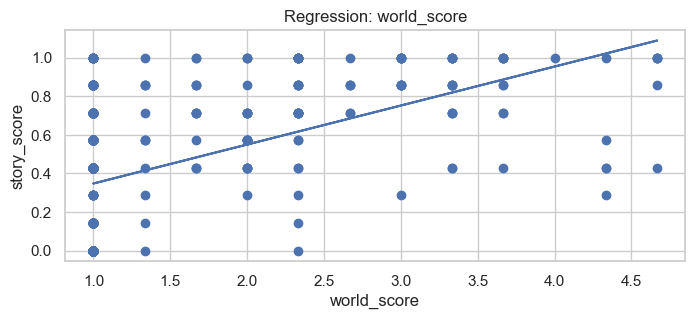

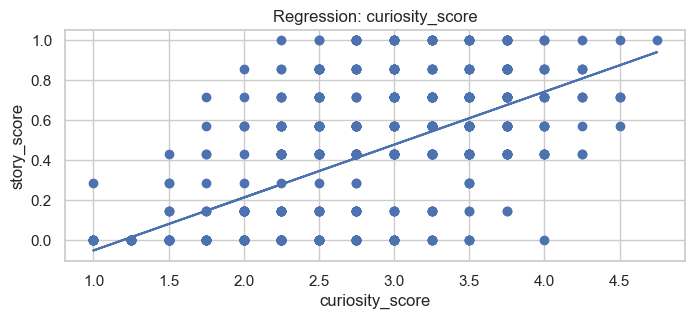

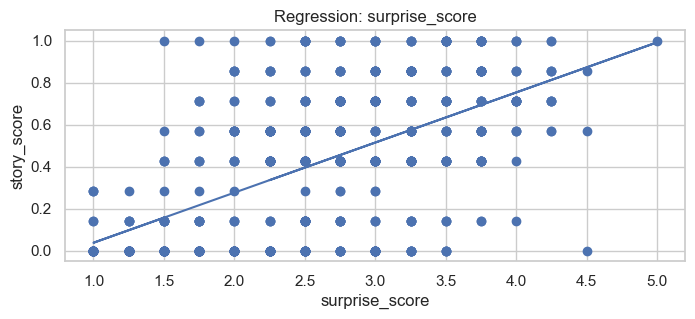

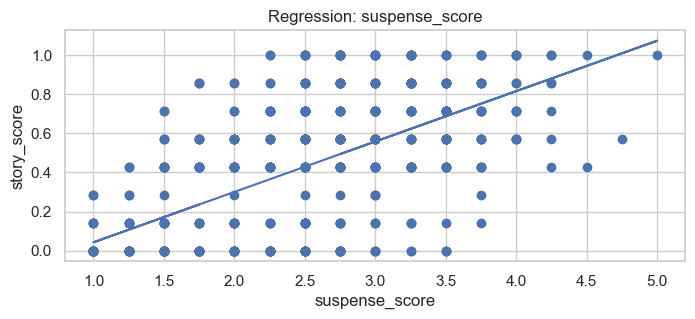

In [158]:
# Plot regression lines
for feature in independent:
    # select the current predictor
    X = df[[feature]]
    # create and fit a new linear regression model
    model = LinearRegression()
    model.fit(X, y)
    # predict y-calues using the regression model
    predictions = model.predict(X)
    
    plt.figure()
    # plot the original data points and the regression line
    plt.scatter(df[feature], y)
    plt.plot(df[feature], predictions)
    # add labels and title
    plt.xlabel(feature)
    plt.ylabel("story_score")
    plt.title(f"Regression: {feature}")

    plt.show()

### Plot residual plots for each independent variable
&rarr; **good residual plot** usually shows:
- points randomly scattered around 0
- no clear curve or pattern

&rarr; **bad residual plot** might show:
- a curve
- clusters 

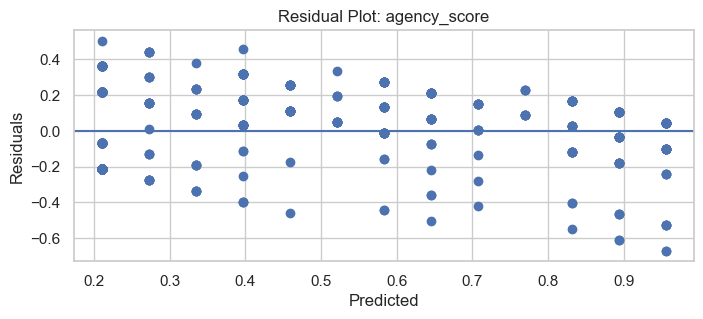

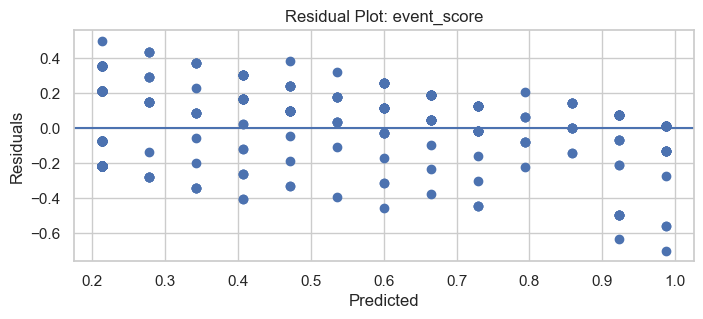

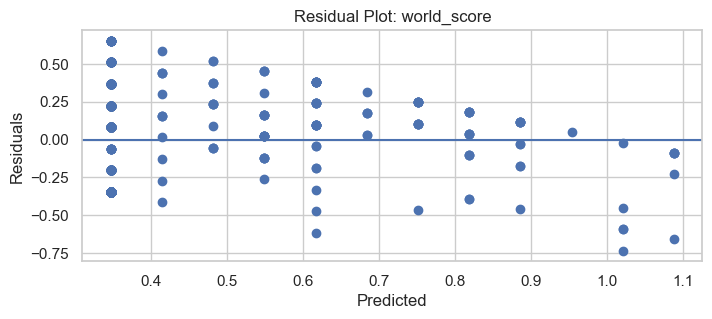

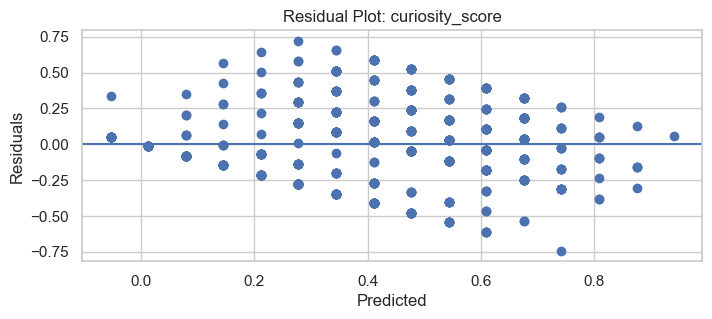

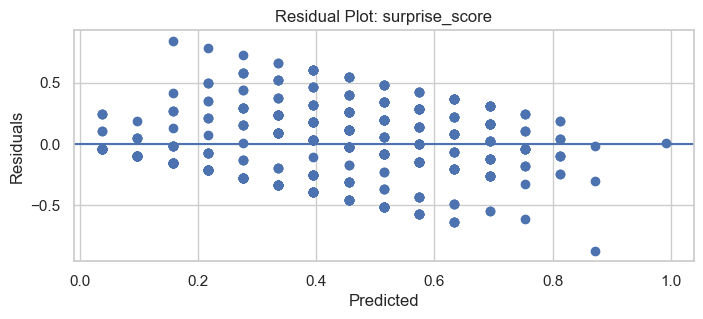

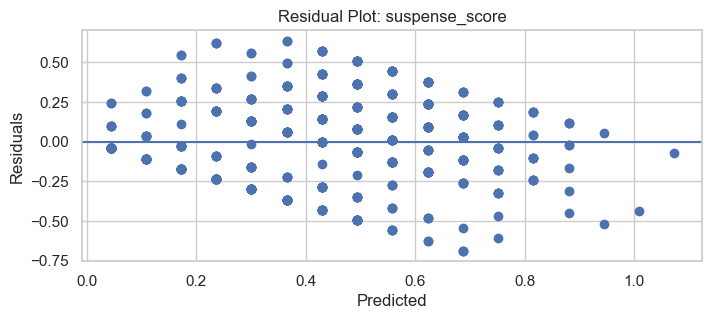

In [155]:
# Residual plots
for feature in independent:
    
    X = df[[feature]]
    
    model = LinearRegression()
    model.fit(X, y)
    
    predictions = model.predict(X)

    #residuals are the difference between actual values and the predicted values
    residuals = y - predictions
    
    plt.figure()
    # plot: x-axis = predcted values, y-axis = residuals
    plt.scatter(predictions, residuals)
    # add a horizontal reference line at 0
    plt.axhline(y=0)
    # labels and title
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot: {feature}")
    
    plt.show()

### Perform Shapiro-Wilk test on residuals
- if **p-value > 0.05**, the residuals are approximately normal
- if **p-value < 0.05**, the residuals are not normally distributed

In [156]:
# Shapiro-Wilk Test 
for i, feature in enumerate(features):
    
    X = df[[feature]]
    
    model = LinearRegression()
    model.fit(X, y)
    
    predictions = model.predict(X)
    
    residuals = y - predictions
    # perform the Shapiro-Wilk test on the residuals
    shapiro_test = stats.shapiro(residuals)
    
    print(f"\nShapiro test for {feature}")
    print(shapiro_test)

    # Add Shapiro results to the existing results dictionary
    results[i]["shapiro_statistic"] = shapiro_test.statistic
    results[i]["shapiro_pvalue"] = shapiro_test.pvalue


Shapiro test for agency_score
ShapiroResult(statistic=np.float64(0.9433870313864502), pvalue=np.float64(1.2397856766786148e-14))

Shapiro test for event_score
ShapiroResult(statistic=np.float64(0.9426995145578432), pvalue=np.float64(9.875589868195722e-15))

Shapiro test for world_score
ShapiroResult(statistic=np.float64(0.9143422733035227), pvalue=np.float64(3.12252075193189e-18))

Shapiro test for curiosity_score
ShapiroResult(statistic=np.float64(0.9887298863187977), pvalue=np.float64(0.00010538841050254437))

Shapiro test for surprise_score
ShapiroResult(statistic=np.float64(0.9955295255509535), pvalue=np.float64(0.07191333447923529))

Shapiro test for suspense_score
ShapiroResult(statistic=np.float64(0.994187025887173), pvalue=np.float64(0.01790913418680829))


### Summary table
You can create a table to have all the results in one place for better visibility &rarr; help us determine which variable predicts story_score best

In [157]:
# Create summary table from the stored results
summary_table = pd.DataFrame(results)
# Round values for readability
summary_table = summary_table.round(4)
# Sort by R² score from highest to lowest
summary_table = summary_table.sort_values("r2_score", ascending=False)

summary_table

,variable,intercept,slope,r2_score,shapiro_statistic,shapiro_pvalue
1,event_score,0.0202,0.1933,0.5971,0.9427,0.0000
0,agency_score,0.0244,0.1863,0.5808,0.9434,0.0000
5,suspense_score,-0.2145,0.2576,0.4214,0.9942,0.0179
3,curiosity_score,-0.3195,0.2655,0.3614,0.9887,0.0001
4,surprise_score,-0.2014,0.2386,0.3427,0.9955,0.0719
2,world_score,0.1454,0.2020,0.2044,0.9143,0.0000
